# Day39) 30-apr-25

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EX 1) Categorical data

In [4]:
# Assigning features and label variables
weather=['Sunny','Overcast','Rainy','Rainy','Rainy','Overcast','Sunny','Sunny','Rainy','Sunny','Overcast','Overcast','Rainy']
temp=['Hot','Hot','Mild','Cool','Cool','Cool','Mild','Cool','Mild','Mild','Mild','Hot','Mild']
humidity=['High','High','High','Normal','Normal','Normal','High','Normal','Normal','Normal','High','Normal','High']
play=['No','Yes','Yes','Yes','No','Yes','No','Yes','Yes','Yes','Yes','Yes','No']

In [12]:
from sklearn.preprocessing  import LabelEncoder

In [14]:
lab_encoder=LabelEncoder()

In [20]:
weather_encoded=lab_encoder.fit_transform(weather)
print(weather_encoded)

[2 0 1 1 1 0 2 2 1 2 0 0 1]


In [24]:
temp_encoded=lab_encoder.fit_transform(temp)
humidity_encoded=lab_encoder.fit_transform(humidity)
play_encoded=lab_encoder.fit_transform(play)

In [26]:
features=list(zip(weather_encoded,temp_encoded,humidity_encoded))
print(features)

[(2, 1, 0), (0, 1, 0), (1, 2, 0), (1, 0, 1), (1, 0, 1), (0, 0, 1), (2, 2, 0), (2, 0, 1), (1, 2, 1), (2, 2, 1), (0, 2, 0), (0, 1, 1), (1, 2, 0)]


In [28]:
type(features)

list

- Build the model

In [35]:
from sklearn.naive_bayes import CategoricalNB
naiveb_model=CategoricalNB()

In [42]:
naiveb_model.fit(features,play_encoded)

CategoricalNB()

- Train the model

In [44]:
y_hat=naiveb_model.predict(features)
print(y_hat)

[0 1 0 1 1 1 0 1 1 1 1 1 0]


In [ ]:
- Evaluate the model 

In [46]:
from sklearn.metrics import confusion_matrix,classification_report

In [48]:
cm=confusion_matrix(play_encoded,y_hat)
clf_rpt=classification_report(play_encoded,y_hat)

print(cm)
print(clf_rpt)

[[3 1]
 [1 8]]
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.89      0.89      0.89         9

    accuracy                           0.85        13
   macro avg       0.82      0.82      0.82        13
weighted avg       0.85      0.85      0.85        13



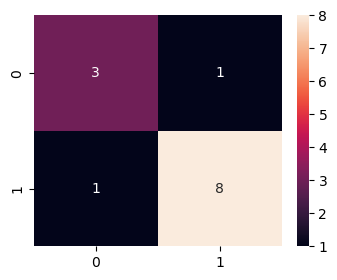

In [52]:
plt.figure(figsize=(4,3))
sns.heatmap(cm,annot=True)
plt.show()

# EX 2) count and discrit data

In [57]:
diabetis_data=pd.read_csv('pima_indians_diabetes.csv')
diabetis_data.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [63]:
x=diabetis_data.iloc[:,0:8]
y=diabetis_data.iloc[:,8:9]

In [68]:
from sklearn.model_selection import train_test_split

In [72]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [74]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((614, 8), (154, 8), (614, 1), (154, 1))

- BUild the model

In [79]:
from sklearn.naive_bayes import GaussianNB

In [87]:
gaun=GaussianNB() # initiate the model
gaun.fit(x_train,y_train)

C:\Users\Pandhari\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

- Predict

In [90]:
yhat_train=gaun.predict(x_train)

- evaluate the model with xtrain

In [92]:
cm_train=confusion_matrix(y_train,yhat_train)
clf_report=classification_report(y_train,yhat_train)
print(cm_train,clf_report)

[[338  63]
 [ 89 124]]               precision    recall  f1-score   support

           0       0.79      0.84      0.82       401
           1       0.66      0.58      0.62       213

    accuracy                           0.75       614
   macro avg       0.73      0.71      0.72       614
weighted avg       0.75      0.75      0.75       614



- evaluate the model with xtest

In [100]:
x_test

,preg,plas,pres,skin,test,mass,pedi,age
668,6,98,58,33,190,34.0,0.430,43
324,2,112,75,32,0,35.7,0.148,21
624,2,108,64,0,0,30.8,0.158,21
690,8,107,80,0,0,24.6,0.856,34
473,7,136,90,0,0,29.9,0.210,50
...,...,...,...,...,...,...,...,...
355,9,165,88,0,0,30.4,0.302,49
534,1,77,56,30,56,33.3,1.251,24
344,8,95,72,0,0,36.8,0.485,57
296,2,146,70,38,360,28.0,0.337,29


In [102]:
yhat_test=gaun.predict(x_test)
cm_test=confusion_matrix(y_test,yhat_test)
clf_report_test=classification_report(y_test,yhat_test)
print(cm_test,clf_report_test)

[[79 20]
 [16 39]]               precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154

